**STEP-1: Install Required Libraries**

In [ ]:
!pip install mlxtend

**STEP-2: Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

import warnings
warnings.filterwarnings('ignore')

**STEP-3: Load Dataset**

In [ ]:
groceries = pd.read_csv("Groceries_dataset.csv")

print("Dataset Shape:", groceries.shape)
groceries.head()

Dataset Shape: (38765, 3)


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


**STEP-4: Check Dataset Information**

In [ ]:
groceries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [ ]:
groceries.describe()

,Member_number
count,38765.000000
mean,3003.641868
std,1153.611031
min,1000.000000
25%,2002.000000
50%,3005.000000
75%,4007.000000
max,5000.000000


**STEP-5: Rename Columns**

In [ ]:
groceries.rename(columns={
    'Member_number':'id',
    'itemDescription':'item'
}, inplace=True)

groceries.head()

,id,Date,item
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


**STEP-6: Convert Date Column**

In [ ]:
groceries['Date'] = pd.to_datetime(groceries['Date'])

groceries['year'] = groceries['Date'].dt.year
groceries['month'] = groceries['Date'].dt.month
groceries['day'] = groceries['Date'].dt.day
groceries['weekday'] = groceries['Date'].dt.weekday

**STEP-7: Rearrange Columns**

In [ ]:
groceries = groceries[['id','Date','year','month','day','weekday','item']]

groceries.head()

,id,Date,year,month,day,weekday,item
0,1808,2015-07-21,2015,7,21,1,tropical fruit
1,2552,2015-01-05,2015,1,5,0,whole milk
2,2300,2015-09-19,2015,9,19,5,pip fruit
3,1187,2015-12-12,2015,12,12,5,other vegetables
4,3037,2015-02-01,2015,2,1,6,whole milk


**STEP-8: Monthly Sales Visualization**

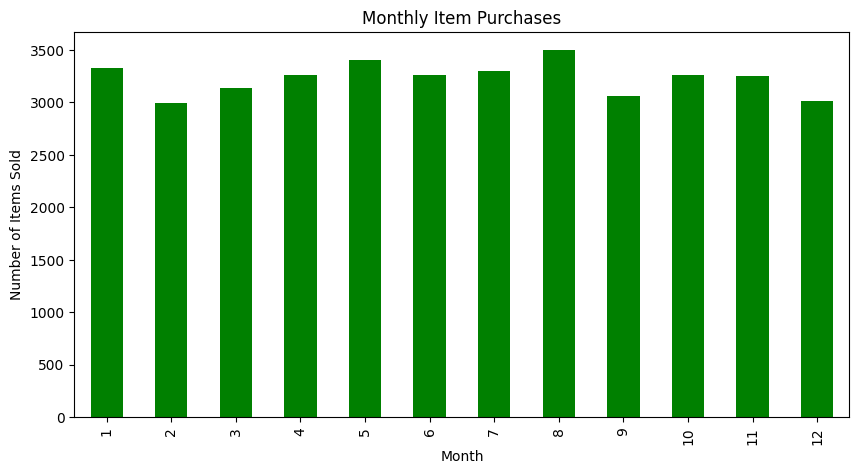

In [ ]:
monthly_sales = groceries.groupby('month')['item'].count()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar', color='green')
plt.title("Monthly Item Purchases")
plt.xlabel("Month")
plt.ylabel("Number of Items Sold")
plt.show()

**STEP-9: Weekday Transactions**

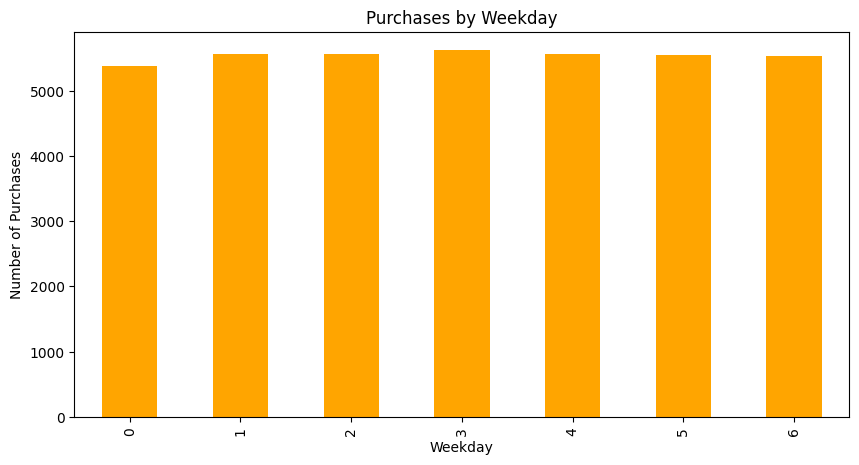

In [ ]:
weekday_sales = groceries.groupby('weekday')['item'].count()

plt.figure(figsize=(10,5))
weekday_sales.plot(kind='bar', color='orange')
plt.title("Purchases by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Purchases")
plt.show()

**STEP-10: Top 10 Products**

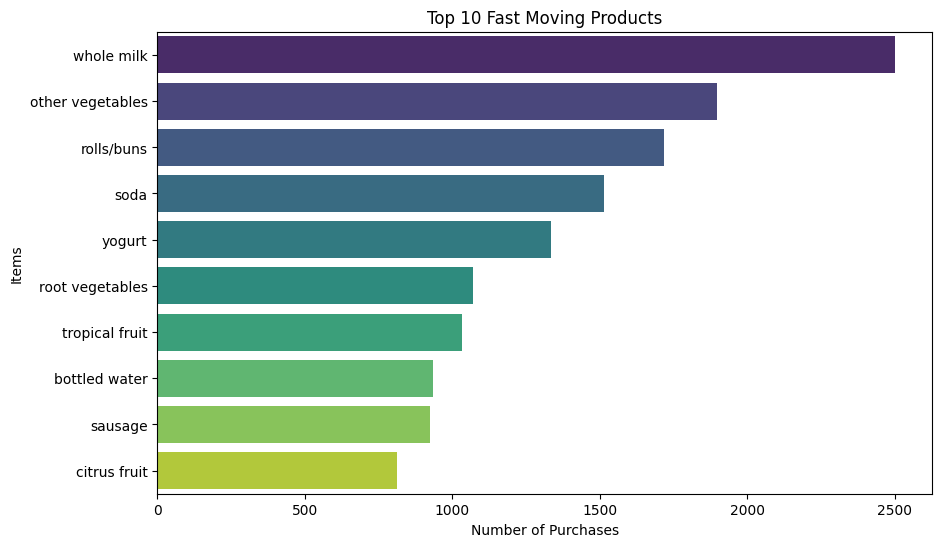

In [ ]:
top_items = groceries['item'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_items.values, y=top_items.index, palette="viridis")

plt.title("Top 10 Fast Moving Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Items")
plt.show()

**STEP-11: Bottom 10 Products**

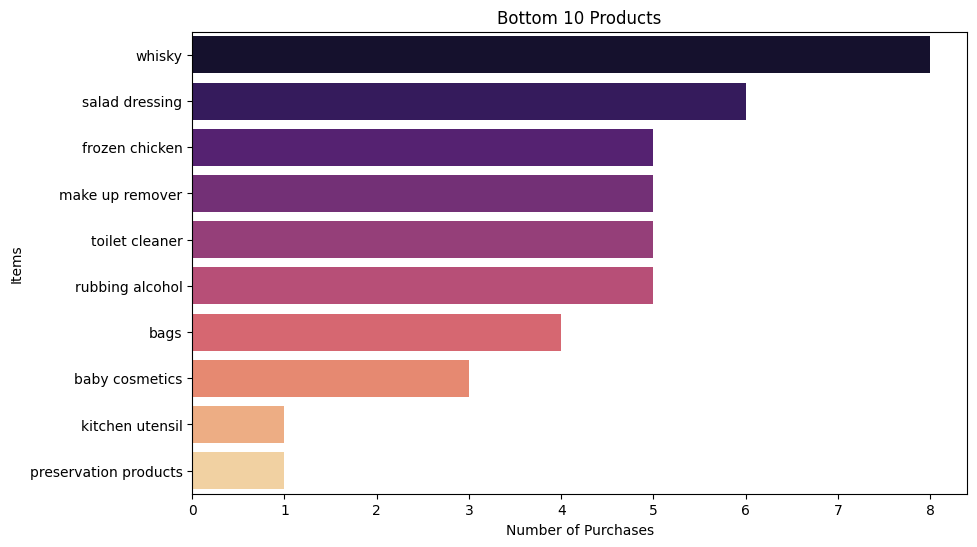

In [ ]:
bottom_items = groceries['item'].value_counts().tail(10)

plt.figure(figsize=(10,6))
sns.barplot(x=bottom_items.values, y=bottom_items.index, palette="magma")

plt.title("Bottom 10 Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Items")
plt.show()

**STEP-12: Prepare Basket Data**

In [ ]:
basket = (groceries
          .groupby(['id','item'])['item']
          .count()
          .unstack()
          .fillna(0))

**STEP-13: Encode Data**

In [ ]:
def encode(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

basket_sets = basket.applymap(encode)

basket_sets.head()

item,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
id,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1001,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,1,0,0
1002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


**STEP-14: Apply Apriori Algorithm**

In [ ]:
frequent_itemsets = apriori(basket_sets,
                            min_support=0.02,
                            use_colnames=True)

frequent_itemsets.head()

,support,itemsets
0,0.078502,(UHT-milk)
1,0.031042,(baking powder)
2,0.119548,(beef)
3,0.079785,(berries)
4,0.062083,(beverages)


**STEP-15: Generate Association Rules**

In [ ]:
rules = association_rules(frequent_itemsets,
                          metric="lift",
                          min_threshold=1)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(UHT-milk),(bottled water),0.078502,0.213699,0.021293,0.271242,1.269268,1.0,0.004517,1.078960,0.230217,0.078598,0.073181,0.185441
1,(bottled water),(UHT-milk),0.213699,0.078502,0.021293,0.099640,1.269268,1.0,0.004517,1.023477,0.269801,0.078598,0.022939,0.185441
2,(other vegetables),(UHT-milk),0.376603,0.078502,0.038994,0.103542,1.318979,1.0,0.009430,1.027933,0.387936,0.093711,0.027174,0.300137
3,(UHT-milk),(other vegetables),0.078502,0.376603,0.038994,0.496732,1.318979,1.0,0.009430,1.238697,0.262440,0.093711,0.192700,0.300137
4,(UHT-milk),(rolls/buns),0.078502,0.349666,0.031042,0.395425,1.130863,1.0,0.003592,1.075687,0.125578,0.078165,0.070361,0.242100


**STEP-16: Support vs Confidence Plot**

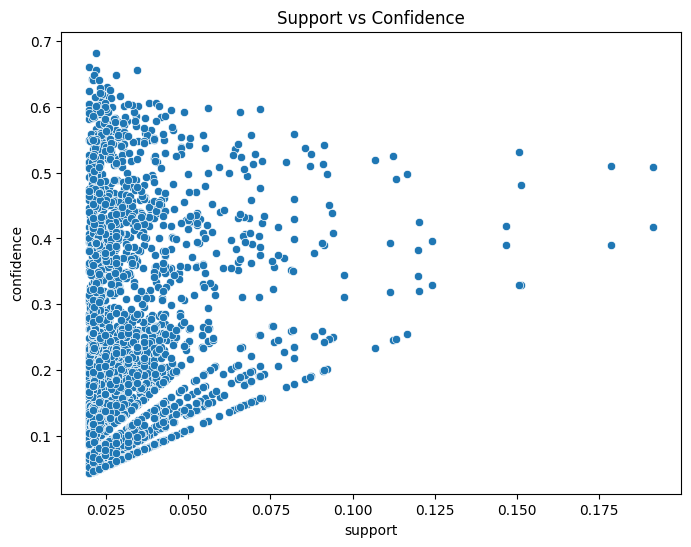

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="support",
                y="confidence",
                data=rules)

plt.title("Support vs Confidence")
plt.show()

**STEP-17: Support vs Lift Plot**

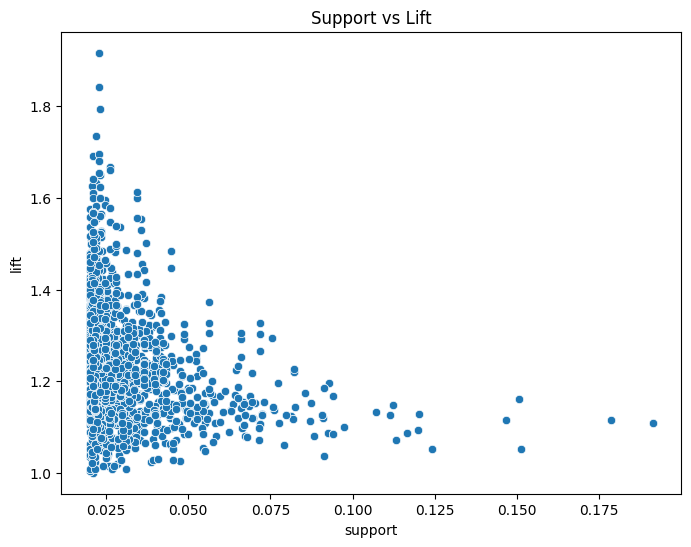

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="support",
                y="lift",
                data=rules)

plt.title("Support vs Lift")
plt.show()

**STEP-18: Confidence vs Lift Plot**

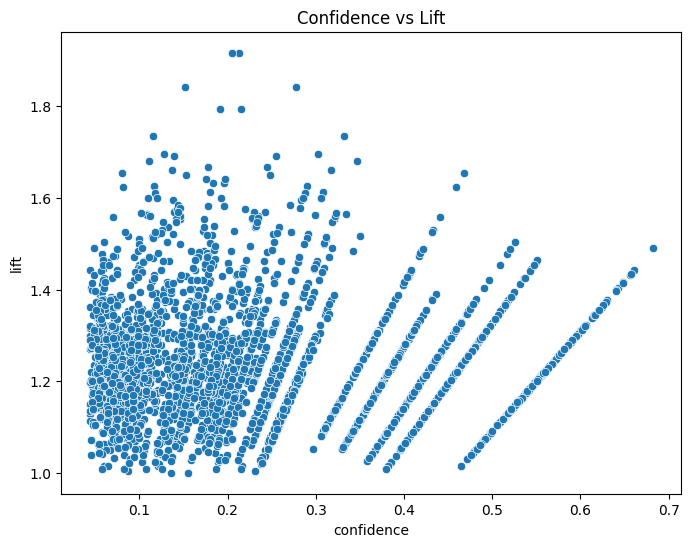

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="confidence",
                y="lift",
                data=rules)

plt.title("Confidence vs Lift")
plt.show()

**STEP-19: Heatmap of Association Rules**

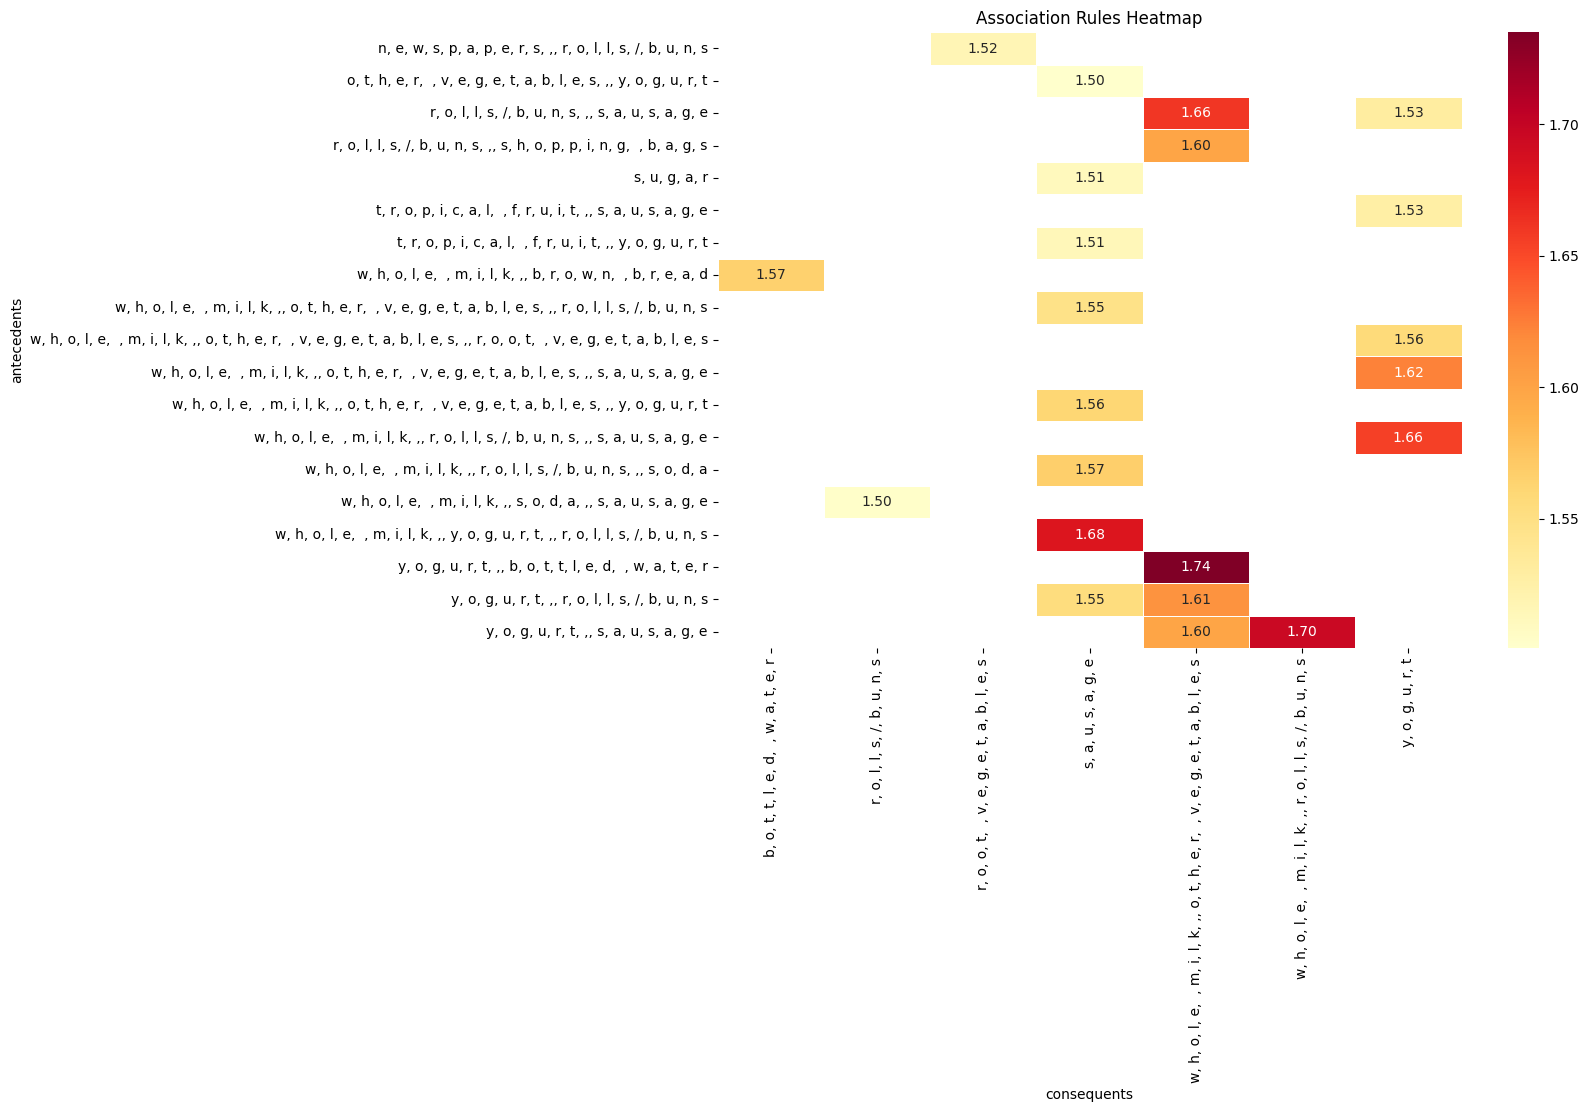

In [ ]:
strong_rules = rules[(rules['lift'] > 1.5) & (rules['confidence'] > 0.3)]

strong_rules['antecedents'] = strong_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
strong_rules['consequents'] = strong_rules['consequents'].apply(lambda x: ', '.join(list(x)))

pivot = strong_rules.pivot(index='antecedents',
                           columns='consequents',
                           values='lift')

plt.figure(figsize=(12,8))

sns.heatmap(pivot,
            cmap="YlOrRd",
            annot=True,
            fmt=".2f",
            linewidths=0.5)

plt.title("Association Rules Heatmap")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()